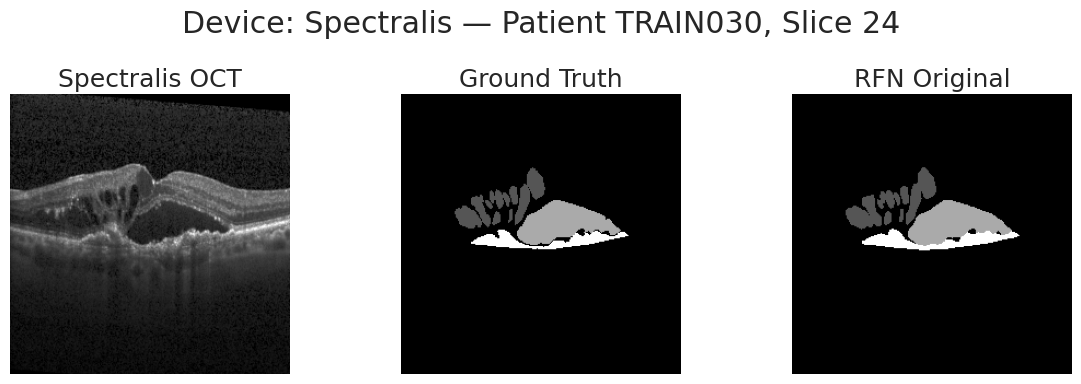

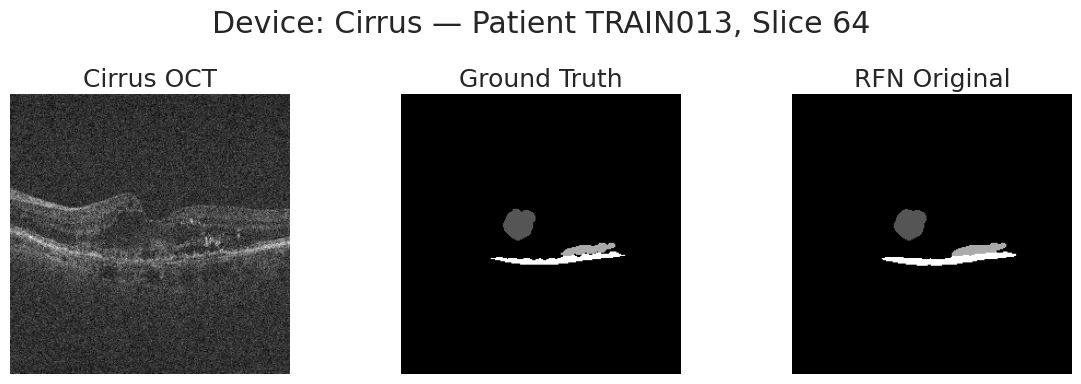

In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from DataReader import DataReader
from losses    import Losses

# Configuration
devices    = ['Spectralis','Cirrus']
data_root  = 'RetouchData'
model_root = 'Spectralis_Cirrus_ori'

patient_map = {
    'Spectralis': 'TRAIN030',
    'Cirrus'   : 'TRAIN013'
}

slice_map = {
    'Spectralis': 24,
    'Cirrus'   : 64,
}

# Helpers
data_reader = DataReader()
loss_funcs  = Losses()

def predict_mask(model, img_tensor):
    """
    Predict label mask for HxWx1 image.
    Uses connectivity outputs from the first 32 channels, 
    groups into 4 classes (8 channels each), applies bv_test_new
    to get per-class probability maps, then argmax and label mask.
    """
    out      = model.predict(img_tensor[None], verbose=0)[0]
    conn32   = out[...,:32]
    prob_maps = []
    for cls in range(4):
        cm = conn32[..., cls*8:(cls+1)*8]    # 8-channel group for this class
        pm = loss_funcs.bv_test_new(tf.expand_dims(cm, 0)).numpy()
        prob_maps.append(pm)
    stack = np.stack(prob_maps, axis=-1)    # H x W x 4
    return np.argmax(stack, axis=-1)    # H x W for class labels

def plot_for_device(ds, slice_idx):
    """
    Load model and one OCT slice, then plot 
    raw image, ground truth mask, and predicted mask.
    """
    patient = patient_map[ds]
    # load model
    model = tf.keras.models.load_model(
        f"{model_root}/model_2_epoch30.hdf5",
        custom_objects={'training_loss': loss_funcs.training_loss, 'dice': loss_funcs.dice}
    )

    # load image & ground truth
    img_path = f"{data_root}/{ds}/retouch_data/{patient}/{patient}_oct_{slice_idx:03d}.png"
    img, gt_mask = data_reader.load_image(tf.constant(img_path))
    gt_mask = gt_mask.numpy()[...,0].astype(int)

    # predict
    pred_mask = predict_mask(model, img)

    # plot 
    fig, axs = plt.subplots(1, 3, figsize=(12,4))
    axs[0].imshow(img[...,0], cmap='gray'); axs[0].set_title(f"{ds} OCT"); axs[0].axis('off')
    axs[1].imshow(gt_mask, cmap='gray', vmin=0, vmax=3); axs[1].set_title("Ground Truth"); axs[1].axis('off')
    axs[2].imshow(pred_mask, cmap='gray', vmin=0, vmax=3); axs[2].set_title("RFN Original"); axs[2].axis('off')

    plt.suptitle(f"Device: {ds} — Patient {patient}, Slice {slice_idx}")
    plt.tight_layout()
    plt.show()

plot_for_device('Spectralis', slice_map['Spectralis'])
plot_for_device('Cirrus',  slice_map['Cirrus'])

In [ ]:
%pip install pingouin

     |████████████████████████████████| 198 kB 2.0 MB/s eta 0:00:01
     |████████████████████████████████| 198 kB 16.3 MB/s eta 0:00:01
     |████████████████████████████████| 11.3 MB 39.7 MB/s eta 0:00:01
     |████████████████████████████████| 9.9 MB 103.1 MB/s eta 0:00:01
  Using cached pandas_flavor-0.7.0-py3-none-any.whl (8.4 kB)
     |████████████████████████████████| 293 kB 114.3 MB/s eta 0:00:01
     |████████████████████████████████| 509 kB 110.8 MB/s eta 0:00:01
     |████████████████████████████████| 845 kB 105.1 MB/s eta 0:00:01
     |████████████████████████████████| 232 kB 88.2 MB/s eta 0:00:01
  Created wheel for littleutils: filename=littleutils-0.2.2-py3-none-any.whl size=7026 sha256=15b7f913a3d052442c635975c429306135bd41d029d69181746aa266b4d2524e
  Stored in directory: /home/sxiaoyu/.cache/pip/wheels/d6/64/cd/32819b511a488e4993f2fab909a95330289c3f4e0f6ef4676d
Successfully built littleutils
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import glob
from IPython.display import display, HTML
import pandas as pd
import pingouin as pg

# Configuration
data_root   = 'RetouchData'
model_root  = 'Spectralis_Cirrus_ori'
devices     = [d for d in os.listdir(data_root) if os.path.isdir(os.path.join(data_root, d))][::-2]
classes     = ['Background', 'IRF', 'SRF', 'PED']

# load model
dr    = DataReader()
lf    = Losses()
model = tf.keras.models.load_model(
    f"{model_root}/model_2_epoch30.hdf5",
    custom_objects={'training_loss': lf.training_loss, 'dice': lf.dice}
)

def predict_mask(img):
    out    = model.predict(img[None], verbose=0)[0]
    conn32 = out[..., :32]
    pms    = [lf.bv_test_new(tf.expand_dims(conn32[..., c*8:(c+1)*8], 0)).numpy()
              for c in range(4)]
    return np.argmax(np.stack(pms, -1), -1)

def compute_frac_mat(masks):
    """
    Compute per-slice class fractions
    Returns a (4 x N) array where each entry is fraction of pixels for class c in slice i.
    """
    H, W = masks[0].shape
    mat  = np.zeros((4, len(masks)), dtype=float)
    for i, m in enumerate(masks):
        lbl = (m // 85).astype(int) if m.max() > 3 else m
        for c in range(4):
            mat[c, i] = np.count_nonzero(lbl == c) / (H * W)
    return mat

# sort (device, patient) pairs
pairs = []
for ds in devices:
    rd = os.path.join(data_root, ds, 'retouch_data')
    if os.path.isdir(rd):
        for pat in os.listdir(rd):
            if os.path.isdir(os.path.join(rd, pat)):
                pairs.append((ds, pat))
pairs = sorted(pairs, key=lambda x: (x[0], x[1]))

# metrics
metrics = { ds: {'patients':[], 'sum_ref':[], 'sum_pred':[], 'rms_ref':[], 'rms_pred':[]} for ds, _ in pairs }

for ds in metrics:
    metrics[ds].update({
        'slice_ref':  {cls: [] for cls in classes},
        'slice_pred': {cls: [] for cls in classes},
    })
    
# Loop over every patient in every device
for ds, pat in pairs:
    folder = os.path.join(data_root, ds, 'retouch_data', pat)
    files  = sorted(glob.glob(os.path.join(folder, '*.png')))

    # Collect masks
    gt_masks, pd_masks = [], []
    for fpath in files:
        img, gt = dr.load_image(tf.constant(fpath))
        gt_masks.append(gt.numpy()[..., 0].astype(int))
        pd_masks.append(predict_mask(img))

    # Compute metrics
    gt_mat = compute_frac_mat(gt_masks)
    pd_mat = compute_frac_mat(pd_masks)
    gt_sum = gt_mat.sum(axis=1)
    pd_sum = pd_mat.sum(axis=1)
    gt_rms = np.sqrt(np.mean(gt_mat**2, axis=1))
    pd_rms = np.sqrt(np.mean(pd_mat**2, axis=1))
    
    
    # Aggregate
    metrics[ds]['patients'].append(pat)
    metrics[ds]['sum_ref'].append(gt_sum)
    metrics[ds]['sum_pred'].append(pd_sum)
    metrics[ds]['rms_ref'].append(gt_rms)
    metrics[ds]['rms_pred'].append(pd_rms)
    
    for c_idx, cls in enumerate(classes):
        metrics[ds]['slice_ref'][cls].extend(gt_mat[c_idx].tolist())
        metrics[ds]['slice_pred'][cls].extend(pd_mat[c_idx].tolist())

    # HTML
    html = [f"<h2>Device: {ds} — Patient: {pat}</h2>",
            "<b>Sum & RMS of Fluid Fractions</b>",
            "<table style='border-collapse:collapse'><tr>"
            "<th>Class</th><th>GT Sum</th><th>RFN Sum</th>"
            "<th>GT RMS</th><th>RFN RMS</th></tr>"]
    for i, cls in enumerate(classes):
        html.append(
            f"<tr>"
            f"<td>{cls}</td>"
            f"<td>{gt_sum[i]:.4f}</td><td>{pd_sum[i]:.4f}</td>"
            f"<td>{gt_rms[i]:.4f}</td><td>{pd_rms[i]:.4f}</td>"
            "</tr>"
        )
    html.append("</table><br>")
    # Per-slice fractions
    html.append("<details><summary><b> Per-slice fractions</b></summary>"
                "<table style='border-collapse:collapse'><tr><th>Slice</th>")
    for cls in classes:
        html.append(f"<th>{cls} GT</th><th>{cls} Pred</th>")
    html.append("</tr>")
    for idx in range(gt_mat.shape[1]):
        row = f"<tr><td>Slice {idx+1}</td>"
        for c in range(4):
            row += (f"<td>{gt_mat[c, idx]:.4f}</td>"
                    f"<td>{pd_mat[c, idx]:.4f}</td>")
        html.append(row + "</tr>")
    html.append("</table></details><hr>")
    display(HTML("".join(html)))

2025-07-28 19:15:24.915459: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.11.0
2025-07-28 19:16:01.958871: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2025-07-28 19:16:01.961830: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcuda.so.1
2025-07-28 19:16:02.211545: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1720] Found device 0 with properties: 
pciBusID: 0000:01:00.0 name: NVIDIA A100-SXM4-40GB computeCapability: 8.0
coreClock: 1.41GHz coreCount: 108 deviceMemorySize: 39.38GiB deviceMemoryBandwidth: 1.41TiB/s
2025-07-28 19:16:02.211606: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.11.0
2025-07-28 19:16:02.522096: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcublas.so.11
2

In [ ]:
print("=== Patient-Level ICC(A,1) by Device & Class ===")
for ds in sorted(metrics):
    print(f"\n--- Device: {ds} ---")
    pats     = metrics[ds]['patients']
    ref_sum  = np.vstack(metrics[ds]['sum_ref'])
    pred_sum = np.vstack(metrics[ds]['sum_pred'])
    ref_rms  = np.vstack(metrics[ds]['rms_ref'])
    pred_rms = np.vstack(metrics[ds]['rms_pred'])
    
    for idx, cls in enumerate(classes):
        # Sum of fractions
        scores = np.vstack([ref_sum[:, idx], pred_sum[:, idx]]).T.flatten()
        df = pd.DataFrame({
            'subject': np.repeat(pats, 2),            # two rows per patient
            'rater':   np.tile(['ref', 'vfm'], len(pats)),
            'value':   scores
        })
        icc_tbl = pg.intraclass_corr(
            data=df,
            targets='subject',
            raters='rater',
            ratings='value'
        ).round(3)
        row = icc_tbl.loc[icc_tbl['Type']=='ICC2'].iloc[0]
        print(f"{cls:10} SUM ICC(A,1) = {row['ICC']:.3f}   95% CI = {row['CI95%']}")

        # RMS
        scores = np.vstack([ref_rms[:, idx], pred_rms[:, idx]]).T.flatten()
        df = pd.DataFrame({
            'subject': np.repeat(pats, 2),
            'rater':   np.tile(['ref', 'vfm'], len(pats)),
            'value':   scores
        })
        icc_tbl = pg.intraclass_corr(
            data=df,
            targets='subject',
            raters='rater',
            ratings='value'
        ).round(3)
        row = icc_tbl.loc[icc_tbl['Type']=='ICC2'].iloc[0]
        print(f"{cls:10} RMS ICC(A,1) = {row['ICC']:.3f}   95% CI = {row['CI95%']}")


print("\n=== Slice-Level ICC(A,1) by Device & Class ===")
for ds in sorted(metrics):
    print(f"\n--- Device: {ds} ---")
    for cls in classes:
        ref  = np.array(metrics[ds]['slice_ref'][cls])  # GT fraction per slice
        pred = np.array(metrics[ds]['slice_pred'][cls]) # Predicted fraction per slice
        n    = len(ref)

        # 1) All slices
        scores_all = np.vstack([ref, pred]).T.flatten()
        ids_all    = [f"{ds}_slice_{i:03d}" for i in range(n)]
        df_all = pd.DataFrame({
            'subject': np.repeat(ids_all, 2),
            'rater':   np.tile(['ref','vfm'], n),
            'value':   scores_all
        })
        tbl_all = pg.intraclass_corr(
            data=df_all, targets='subject',
            raters='rater', ratings='value'
        ).round(3)
        row_all = tbl_all.loc[tbl_all['Type']=='ICC2'].iloc[0]
        icc_all, ci_all = row_all['ICC'], row_all['CI95%']

        # 2) Fluid only slices (ref > 0)
        idxs = [i for i, v in enumerate(ref) if v > 0]
        if idxs:
            ref_pos   = ref[idxs]
            pred_pos  = pred[idxs]
            scores_pos = np.vstack([ref_pos, pred_pos]).T.flatten()
            ids_pos    = [f"{ds}_slice_{i:03d}" for i in idxs]
            df_pos = pd.DataFrame({
                'subject': np.repeat(ids_pos, 2),
                'rater':   np.tile(['ref','vfm'], len(idxs)),
                'value':   scores_pos
            })
            tbl_pos = pg.intraclass_corr(
                data=df_pos, targets='subject',
                raters='rater', ratings='value'
            ).round(3)
            row_pos = tbl_pos.loc[tbl_pos['Type']=='ICC2'].iloc[0]
            icc_pos, ci_pos = row_pos['ICC'], row_pos['CI95%']
        else:
            icc_pos, ci_pos = None, None

        # Print
        if icc_pos is not None:
            print(f"{cls:10} All-slices ICC(A,1) = {icc_all:.3f} {ci_all}   "
                  f"Fluid-only ICC(A,1) = {icc_pos:.3f} {ci_pos}")
        else:
            print(f"{cls:10} All-slices ICC(A,1) = {icc_all:.3f} {ci_all}   "
                  f"No fluid-positive slices → fluid-only ICC undefined")



=== Patient-Level ICC(A,1) by Device & Class ===

--- Device: Cirrus ---
IRF        SUM ICC(A,1) = 0.990   95% CI = [0.98 1.  ]
IRF        RMS ICC(A,1) = 0.991   95% CI = [0.98 1.  ]
SRF        SUM ICC(A,1) = 0.992   95% CI = [0.98 1.  ]
SRF        RMS ICC(A,1) = 0.993   95% CI = [0.98 1.  ]
PED        SUM ICC(A,1) = 0.999   95% CI = [1. 1.]
PED        RMS ICC(A,1) = 0.999   95% CI = [1. 1.]

--- Device: Spectralis ---
IRF        SUM ICC(A,1) = 0.996   95% CI = [0.98 1.  ]
IRF        RMS ICC(A,1) = 0.996   95% CI = [0.98 1.  ]
SRF        SUM ICC(A,1) = 0.995   95% CI = [0.99 1.  ]
SRF        RMS ICC(A,1) = 0.996   95% CI = [0.99 1.  ]
PED        SUM ICC(A,1) = 0.999   95% CI = [1. 1.]
PED        RMS ICC(A,1) = 1.000   95% CI = [1. 1.]

=== Slice-Level ICC(A,1) by Device & Class ===

--- Device: Cirrus ---
IRF        All-slices ICC(A,1) = 0.990 [0.99 0.99]   Fluid-only ICC(A,1) = 0.985 [0.98 0.99]
SRF        All-slices ICC(A,1) = 0.998 [1. 1.]   Fluid-only ICC(A,1) = 0.997 [1. 1.]
PED  

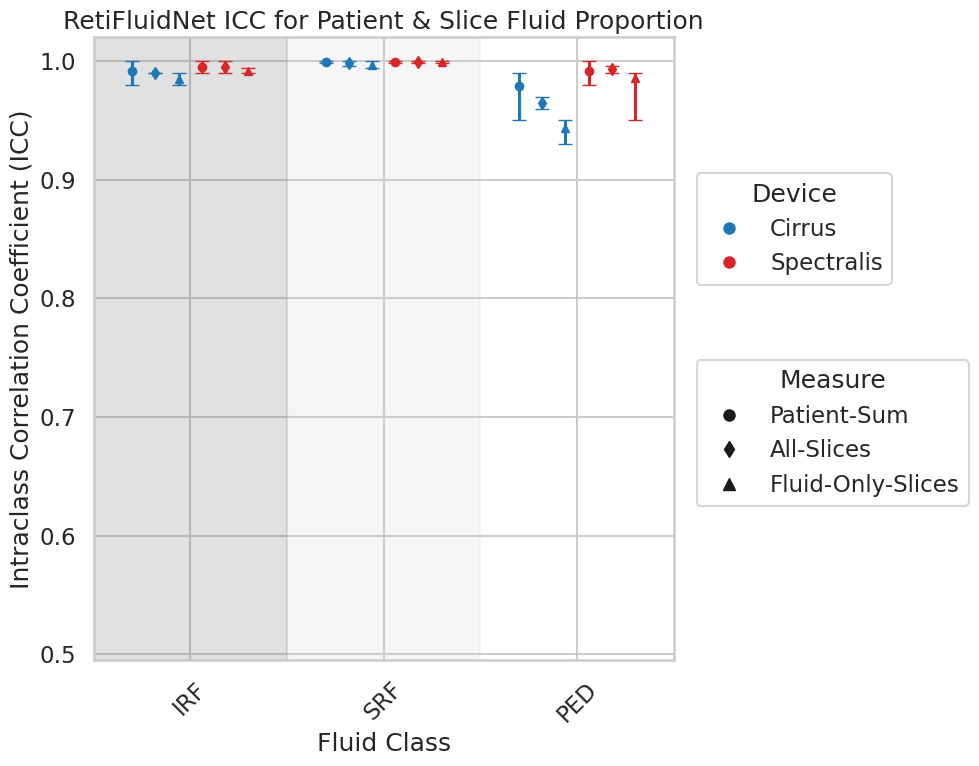

In [ ]:
import seaborn as sns
from matplotlib.lines import Line2D

# 1) Collect ICCs into a tidy DataFrame
devices = sorted(metrics.keys())
classes = list(metrics[devices[0]]['slice_ref'].keys())

records = []
for ds in devices:
    # Patient level sum
    pats     = metrics[ds]['patients']
    ref_sum  = np.vstack(metrics[ds]['sum_ref'])
    pred_sum = np.vstack(metrics[ds]['sum_pred'])
    for idx, cls in enumerate(classes):
        df = pd.DataFrame({
            'subject': np.repeat(pats, 2),
            'rater':   np.tile(['ref','vfm'], len(pats)),
            'value':   np.vstack([ref_sum[:,idx], pred_sum[:,idx]]).T.flatten()
        })
        tbl = pg.intraclass_corr(data=df, targets='subject',
                                 raters='rater', ratings='value').round(3)
        row = tbl.query("Type=='ICC2'").iloc[0]
        lo, hi = row['CI95%']
        records.append({
            'device': ds, 'class': cls, 'measure': 'Patient-Sum',
            'ICC': row['ICC'], 'lo': lo, 'hi': hi
        })
    # Slice-All & Slice-Fluid-Only
    for cls in classes:
        ref_s  = np.array(metrics[ds]['slice_ref'][cls])
        pred_s = np.array(metrics[ds]['slice_pred'][cls])
        n = len(ref_s)
        for measure, mask in [('All-Slices', np.ones(n,bool)),
                              ('Fluid-Only-Slices', ref_s>0)]:
            if not mask.any():
                records.append({
                    'device': ds, 'class': cls, 'measure': measure,
                    'ICC': np.nan, 'lo': np.nan, 'hi': np.nan
                })
                continue
            df = pd.DataFrame({
                'subject': np.repeat(
                    [f"{ds}_slice_{i:03d}" for i in np.where(mask)[0]], 2),
                'rater': np.tile(['ref','vfm'], mask.sum()),
                'value': np.vstack([ref_s[mask], pred_s[mask]]).T.flatten()
            })
            tbl = pg.intraclass_corr(data=df, targets='subject',
                                     raters='rater', ratings='value').round(3)
            row = tbl.query("Type=='ICC2'").iloc[0]
            lo, hi = row['CI95%']
            records.append({
                'device': ds, 'class': cls, 'measure': measure,
                'ICC': row['ICC'], 'lo': lo, 'hi': hi
            })

df_plot = pd.DataFrame(records)

# Prep for plot
dfp = df_plot[df_plot['class']!='Background']   # Drop Background
devices = sorted(dfp['device'].unique())
classes = ['IRF','SRF','PED']
x       = np.arange(len(classes))
width   = 0.12

colors  = {'Cirrus':'tab:blue','Spectralis':'tab:red'}  # Device color map
markers = {'Patient-Sum':'o','All-Slices':'d','Fluid-Only-Slices':'^'}  # Measure markers map
cap = width * 0.4

sns.set(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(12,8))

# shade IRF & SRF regions
ax.axvspan(-0.5,  0.5, color='dimgray',  alpha=0.2)
ax.axvspan( 0.5,  1.5, color='lightgray', alpha=0.2)

# plot
for di, ds in enumerate(devices):
    for mi, measure in enumerate(['Patient-Sum','All-Slices','Fluid-Only-Slices']):
        sub = dfp[(dfp.device==ds)&(dfp.measure==measure)]
        xi  = x + ((di*3 + mi) - 2.5)*width
        lo  = np.abs(sub.ICC - sub.lo)
        hi  = np.abs(sub.hi  - sub.ICC)
        ax.errorbar(
            xi, sub.ICC,
            yerr=[lo,hi],
            marker=markers[measure],
            color=colors[ds],
            ms=6, capsize=5, linestyle="none"
        )

# axes
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45)
ax.set_xlabel("Fluid Class")
ax.set_ylabel("Intraclass Correlation Coefficient (ICC)")
ax.set_title("RetiFluidNet ICC for Patient & Slice Fluid Proportion")
ax.set_xlim(-0.5, len(classes)-0.5) 
ax.set_ylim(0.495,1.02)

# legends
dev_handles = [Line2D([0],[0], marker='o', color=colors[ds], 
                      linestyle='none', markersize=8) for ds in devices]
dev_labels  = [f"{ds}" for ds in devices]
leg1 = ax.legend(dev_handles, dev_labels, title="Device",
                 loc='upper left', bbox_to_anchor=(1.02, 0.8))

meas_handles = [Line2D([0],[0], marker=markers[m], color='k',
                       linestyle='none', markersize=8) for m in ['Patient-Sum','All-Slices','Fluid-Only-Slices']]
meas_labels  = ['Patient‐Sum', 'All-Slices','Fluid-Only-Slices']
leg2 = ax.legend(meas_handles, meas_labels, title="Measure",
                 loc='upper left', bbox_to_anchor=(1.02, 0.5))
ax.add_artist(leg1) 

plt.tight_layout(rect=[0,0,0.85,1])
plt.show()